<a href="https://colab.research.google.com/github/tarshibofficial/Ai-ML/blob/main/210104_logistic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Load from GitHub


In [1]:
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/tarshibofficial/Ai-ML/main/dataset/diabetes.csv"

df = pd.read_csv(url)


#Dataset Explore

In [2]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.shape

(768, 9)

In [4]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [5]:
df.dtypes

,0
Pregnancies,int64
Glucose,int64
BloodPressure,int64
SkinThickness,int64
Insulin,int64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
Outcome,int64


In [6]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [7]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


#Feature Selection

In [9]:
x = df[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
        'Insulin', 'DiabetesPedigreeFunction', 'Age', 'BMI']]

y = df['Outcome']

In [10]:
x.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'DiabetesPedigreeFunction', 'Age', 'BMI'],
      dtype='object')

In [11]:
y.columns

Index(['Outcome'], dtype='object')

#Train Test Split

In [13]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=33, stratify=y)

In [14]:
x_train.shape

(614, 8)

In [15]:
x_test.shape

(154, 8)

#Normalization

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

#Train Linear Regression Model

In [17]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

In [18]:
model.fit(x_train_scaled, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression(max_iter=1000)

In [19]:
train_score = model.score(x_train_scaled, y_train)
test_score = model.score(x_test_scaled, y_test)

print("Training Accuracy:", train_score)
print("Testing Accuracy:", test_score)

Training Accuracy: 0.7719869706840391
Testing Accuracy: 0.7792207792207793


#Sample Prediction Table

In [24]:
y_pred = model.predict(x_test_scaled)


In [25]:
results = pd.DataFrame({
    'Actual Outcome': y_test.to_numpy().ravel(),
    'Predicted Outcome': y_pred.ravel()
})

results.head(20)

,Actual Outcome,Predicted Outcome
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,1,1
7,0,0
8,0,0
9,1,0


#Evaluation Metrics

In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_prob)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("AUC Score:", auc_score)

Accuracy: 0.7792207792207793
Precision: 0.8333333333333334
Recall: 0.46296296296296297
F1-score: 0.5952380952380952
AUC Score: 0.8716666666666667


# Classification Report

In [27]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.95      0.85       100
           1       0.83      0.46      0.60        54

    accuracy                           0.78       154
   macro avg       0.80      0.71      0.72       154
weighted avg       0.79      0.78      0.76       154



# Confusion Matrix

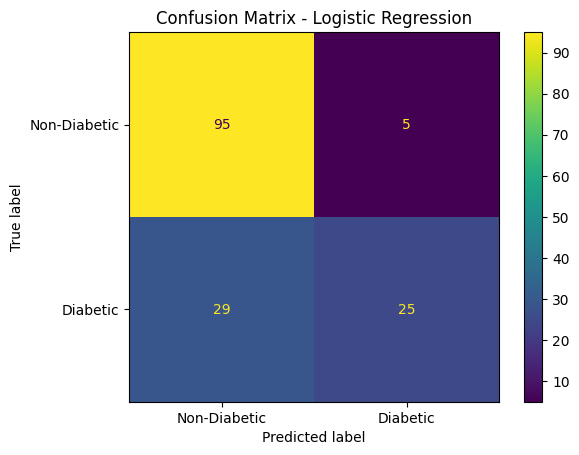

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Non-Diabetic', 'Diabetic']
)

disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

# ROC Curve

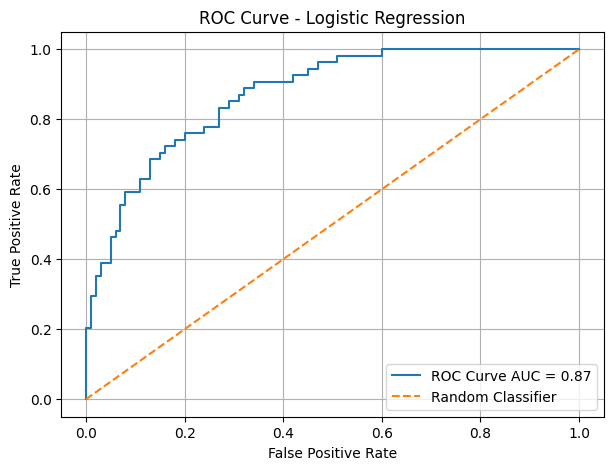

In [31]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label='ROC Curve AUC = %0.2f' % roc_auc)
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Classifier')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.grid(True)
plt.show()

# Correlation Heatmap


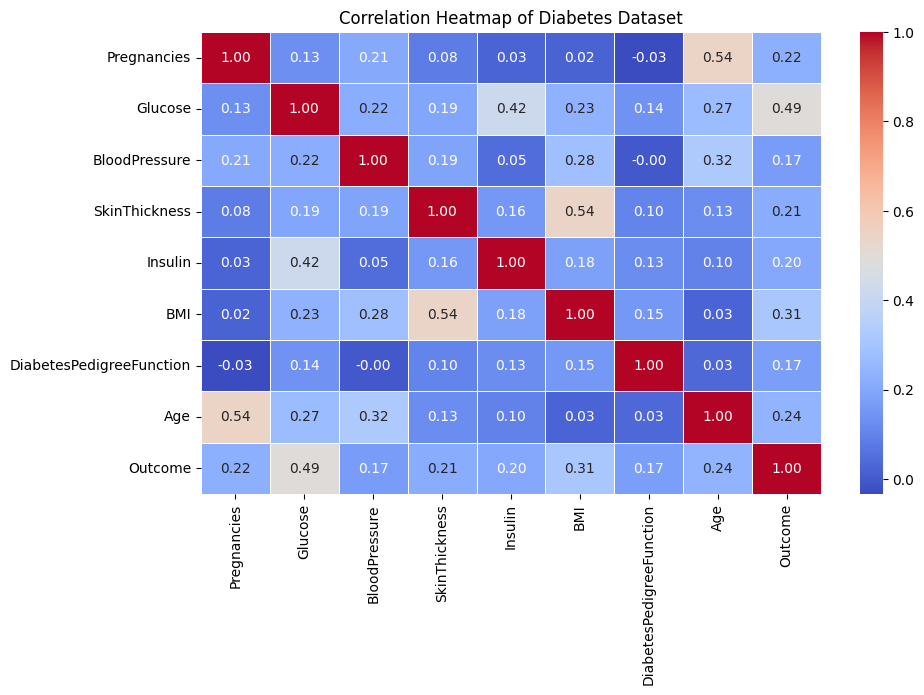

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title("Correlation Heatmap of Diabetes Dataset")
plt.show()